In [1]:
# 日本語対応のモジュールをインストールする(その1)
!pip install japanize-matplotlib
# 日本語対応のモジュールをインストールする(その2)
!apt-get install -y fonts-ipafont-gothic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=ae0dc2359487c21c7b374703aef22919e8a7c32b6ebeb34ea3f2a4fb0497ca81
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-ipafont-mincho
The following NEW packages will be installed:
  fonts-ipafont-gothic fonts-ipafont-mincho
0 upgraded, 2 newly installed, 0 to remove and 3 not upgraded.
Need to get 8,237 kB of archives.
After this operation, 28.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-gothic all 00303-21ubuntu1 [3,513 kB]
Get:2 http://arc

In [2]:
# 各ライブラリーをインポートする
import time, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

try:
    import japanize_matplotlib # noqa
except Exception:
    pass

plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore")
RNG = np.random.default_rng(20260716)

In [3]:
# データ読み込み
LISTINGS_URL = ("https://data.insideairbnb.com/japan/kant%C5%8D/tokyo/"
"2023-06-29/visualisations/listings.csv")

FEAT_NUM = ["latitude", "longitude", "minimum_nights", "number_of_reviews",
"reviews_per_month", "availability_365", "calculated_host_listings_count"]
FEAT_CAT = ["neighbourhood", "room_type"]

def synthesize_listings(n=15000):
    wards = ["Shinjuku", "Shibuya", "Taito", "Sumida", "Toshima", "Nakano", "Setagaya", "Ota", "Katsushika", "Arakawa"]
    wp = dict(zip (wards, [1.0,1.05,0.85,0.75,0.7,0.6,0.55,0.45,0.35,0.4]))
    w = np.array([2.2,2.0,1.6,1.3,1.1,0.9,0.9,0.8,0.7,0.7]); w = w/w.sum()
    ward = RNG.choice (wards, n, p=w)
    rooms = ["Entire home/apt", "Private room", "Hotel room", "Shared room"]
    re_ = {"Entire home/apt": 1.0, "Private room": 0.45, "Hotel room": 0.7, "Shared room":0.25}
    room = RNG.choice(rooms, n, p=[0.62,0.30,0.05,0.03])
    mn = np.clip(RNG.lognormal(0.7,0.8,n).astype(int),1,365)
    nrev = RNG.poisson(np.clip(RNG.lognormal(2.2,1.1,n),0, None)).astype(int)
    rpm = np.round(np.clip(RNG.gamma (1.5,0.7,n),0,None),2)
    av = np.clip((RNG.beta(1.4,1.6,n)*365).astype(int),0,365)
    hl = np.clip(RNG.lognormal(0.6,1.0,n).astype(int), 1, None)
    lat = 35.68 + RNG.normal(0,0.045,n); lon = 139.75 + RNG.normal(0,0.055,n)
    wpar = np.array([wp [x] for x in ward]); ent = (room=="Entire home/apt"); shr = (room=="Shared room")
    price = (3600*np.array([re_[r] for r in room])*(0.6+0.8*wpar)
    *(1+0.9*ent*(wpar>0.8))
    *(0.75+0.5*np.exp(-((av-180)**2)/(2*70**2)))
    *np.where(mn<=3,1.15,np.where(mn>=30,0.8,1.0))
    *(1+0.5*(nrev>20)*ent-0.3*(nrev>20)*shr)
    *(1+RNG.normal(0,0.25,n)))
    price = np.clip(price, 1500, None).astype(int)
    return pd.DataFrame({"neighbourhood": ward, "room_type":room, "latitude":lat.round(5),
    "longitude": lon.round(5),"minimum_nights":mn, "number_of_reviews":nrev,
    "reviews_per_month": rpm, "availability_365":av,
    "calculated_host_listings_count":hl, "price": price})

def load_listings():
    try:
        df = pd.read_csv(LISTINGS_URL)
        df["price"] = (df["price"].astype(str).str.replace(r"[\$,]","", regex=True)
        .replace("", np.nan).astype(float))
        df = df [FEAT_NUM+FEAT_CAT+["price"]].dropna (subset=["price", "room_type", "neighbourhood"])
        df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
        df = df[(df["price"]>0)&(df["price"]<df["price"].quantile(0.99))]
        print(f"[実データ] listings 読み込み: {len(df):,}件")
        return df.reset_index(drop=True), True
    except Exception as e:
        print(f"[フォールバック] 実データ取得不可({type(e).__name__})。合成データで続行。")
        return synthesize_listings(), False

df, IS_REAL = load_listings()
thr = int(df["price"].median())
y = (df["price"] >= thr).astype(int).values
X = df [FEAT_NUM+FEAT_CAT].copy()
print(f"目的変数=高価格帯か(中央値 {thr}) 正例率 {y.mean():.3f} 件数 {len(df):,}")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score

pre = ColumnTransformer([("cat", OrdinalEncoder (handle_unknown="use_encoded_value",
unknown_value =-1), FEAT_CAT)], remainder="passthrough")

def make_gbdt():
    return Pipeline ([("pre", pre),("clf", HistGradientBoostingClassifier(
    categorical_features =[0,1], random_state =0))])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size =0.25, random_state =0, stratify=y)
gb = make_gbdt(); gb.fit(Xtr, ytr)
proba = gb.predict_proba(Xte) [:,1]
pred = (proba >=0.5) .astype(int)
print(f"[分類器]全体正解率 {accuracy_score (yte, pred):.3f}")

[実データ] listings 読み込み: 11,055件
目的変数=高価格帯か(中央値 14286) 正例率 0.502 件数 11,055
[分類器]全体正解率 0.783



=== ① 公平性ギャップ (room_type群別) ===
 Entire home/apt  n= 2038 陽性予測率=0.612 TPR=0.855 正解率=0.771
 Private room     n=  594 陽性予測率=0.379 TPR=0.714 正解率=0.803
 Hotel room       n=   69 陽性予測率=0.522 TPR=0.848 正解率=0.812
 Shared room      n=   63 陽性予測率=0.000 TPR=0.000 正解率=0.937
 → 陽性予測率の群間差(demographic parity gap) = 0.612
  TPRの群間差(equal opportunity gap) = 0.855
 しきい値別 陽性予測率ギャップ:
 t=0.3: gap=0.806
 t=0.4: gap=0.722
 t=0.5: gap=0.612
 t=0.6: gap=0.485
 t=0.7: gap=0.362


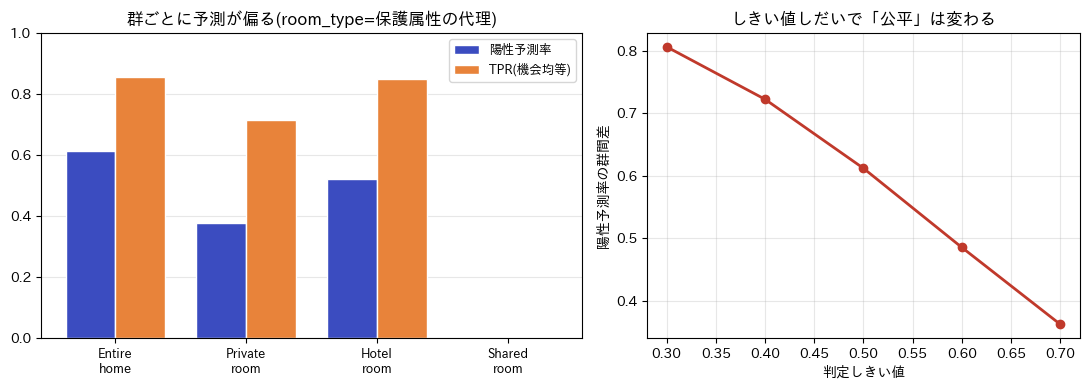

In [5]:
print("\n=== ① 公平性ギャップ (room_type群別) ===")
g = Xte ["room_type"].values
groups = ["Entire home/apt", "Private room", "Hotel room", "Shared room"]
rows=[]
for grp in groups:
    m=(g==grp)
    if m.sum()==0: continue
    ppr = pred[m].mean()
    # 陽性予測率(demographic parity)
    tpr = pred[m][yte[m]==1].mean() if (yte[m]==1).sum()>0 else np.nan # 機会均等
    acc = accuracy_score(yte [m], pred [m])
    rows.append((grp, m.sum(), ppr, tpr, acc))
    print(f" {grp:16s} n={m.sum():5d} 陽性予測率={ppr:.3f} TPR={tpr:.3f} 正解率={acc:.3f}")

pdp = np.nanmax ([r[2] for r in rows]) - np.nanmin([r[2] for r in rows])
eop = np.nanmax ([r[3] for r in rows]) - np.nanmin ([r[3] for r in rows])
print(f" → 陽性予測率の群間差(demographic parity gap) = {pdp:.3f}")
print(f"  TPRの群間差(equal opportunity gap) = {eop:.3f}")

# しきい値を動かすとギャップが変わる
print(" しきい値別 陽性予測率ギャップ:")
thr_list=[0.3,0.4,0.5,0.6,0.7]; gap_by_t =[]
for t in thr_list:
    pr = (proba>=t).astype(int)
    pprs=[pr[g==grp].mean() for grp in groups if (g==grp).sum()>0]
    gp=max(pprs)-min(pprs); gap_by_t.append(gp)
    print(f" t={t:.1f}: gap={gp:.3f}")

#図①
fig, (a1,a2)=plt.subplots (1,2, figsize =(11,4), gridspec_kw={"width_ratios":[1.25,1]})

labels=[r[0].replace("Entire home/apt", "Entire\nhome").replace("Private room", "Private\nroom")
.replace("Hotel room", "Hotel\nroom").replace("Shared room", "Shared\nroom") for r in rows]
xx=np.arange(len(rows)); wd=0.38

a1.bar(xx-wd/2, [r[2] for r in rows], wd, label="陽性予測率",color="#3B4CC0",edgecolor="white")
a1.bar(xx+wd/2, [r[3] for r in rows], wd, label="TPR(機会均等)",color="#E8833A",edgecolor="white")
a1.set_xticks(xx); a1.set_xticklabels (labels, fontsize =9); a1.set_ylim(0,1)
a1.set_title("群ごとに予測が偏る(room_type=保護属性の代理)"); a1.legend(fontsize=9)
a1.grid(axis="y", alpha=.3); a1.set_axisbelow (True)

a2.plot(thr_list,gap_by_t,"o-",color="#C0392B", lw=2)
a2.set_xlabel("判定しきい値"); a2.set_ylabel("陽性予測率の群間差")
a2.set_title("しきい値しだいで「公平」は変わる"); a2.grid(alpha =.3); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()


=== ② 準識別子による再識別(k-匿名性) ===
 地域のみ                   準識別子1個→ 一意 (k=1) な割合   0.0% (0件)
 +部屋タイプ                 準識別子2個→ 一意 (k=1) な割合   0.1% (9件)
 +稼働月数                  準識別子3個→ 一意 (k=1) な割合   1.7% (190件)
 +緯度経度(小数2桁)            準識別子5個→ 一意 (k=1) な割合  14.8% (1635件)
 +掲載件数                  準識別子6個→ 一意 (k=1) な割合  32.7% (3614件)


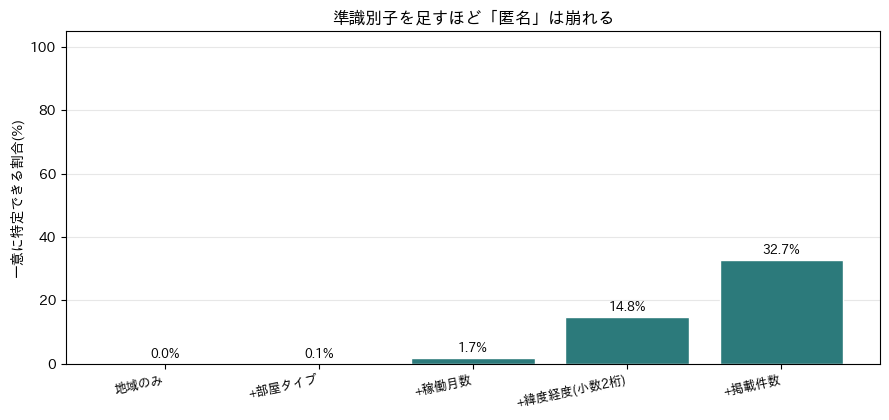

In [6]:
print("\n=== ② 準識別子による再識別(k-匿名性) ===")
d = df.copy()
d["lat2"]=d["latitude"].round(2); d["lon2"]=d["longitude"].round(2)
d["av_bin"]=(d["availability_365"]//30)
qi_sets=[
    (["neighbourhood"], "地域のみ"),
    (["neighbourhood", "room_type"], "+部屋タイプ"),
    (["neighbourhood", "room_type", "av_bin"], "+稼働月数"),
    (["neighbourhood","room_type","av_bin","lat2","lon2"], "+緯度経度(小数2桁)"),
    (["neighbourhood", "room_type","av_bin","lat2","lon2", "calculated_host_listings_count"],"+掲載件数")
]

uniq_frac=[]; labels2=[]
for qi,name in qi_sets:
    grp_sizes = d.groupby(qi).size()
    key = d.groupby(qi).ngroup().map(grp_sizes.reset_index(drop=True))
    sizes = d.groupby(qi)[qi[0]].transform("size")
    uf = (sizes ==1).mean()
    uniq_frac.append(uf); labels2.append(name)
    print(f" {name:22s} 準識別子{len(qi)}個→ 一意 (k=1) な割合 {uf*100:5.1f}% ({int((sizes ==1) .sum())}件)")

fig, ax=plt.subplots(figsize=(9,4.3))
bars=ax.bar(range(len(uniq_frac)), [u*100 for u in uniq_frac], color="#2C7A7B", edgecolor="white")
for i,u in enumerate (uniq_frac):
    ax.text(i,u*100+1, f"{u*100:.1f}%",ha="center",va="bottom", fontsize =9)
ax.set_xticks (range (len(labels2))); ax.set_xticklabels (labels2, fontsize =9, rotation =12,ha="right")
ax.set_ylabel("一意に特定できる割合(%)"); ax.set_ylim (0,105)
ax.set_title("準識別子を足すほど「匿名」は崩れる")
ax.grid(axis="y", alpha=.3); ax.set_axisbelow (True)
plt.tight_layout(); plt.show()


=== ③ 差分プライバシー(区ごとの件数クエリにLaplaceノイズ) ===
 ε=0.1:平均絶対誤差    9.9 件(scale=10.0)
 ε=0.5:平均絶対誤差    2.0 件(scale=2.0)
 ε=1.0:平均絶対誤差    1.0 件(scale=1.0)
 ε=2.0:平均絶対誤差    0.5 件(scale=0.5)
 ε=5.0:平均絶対誤差    0.2 件(scale=0.2)


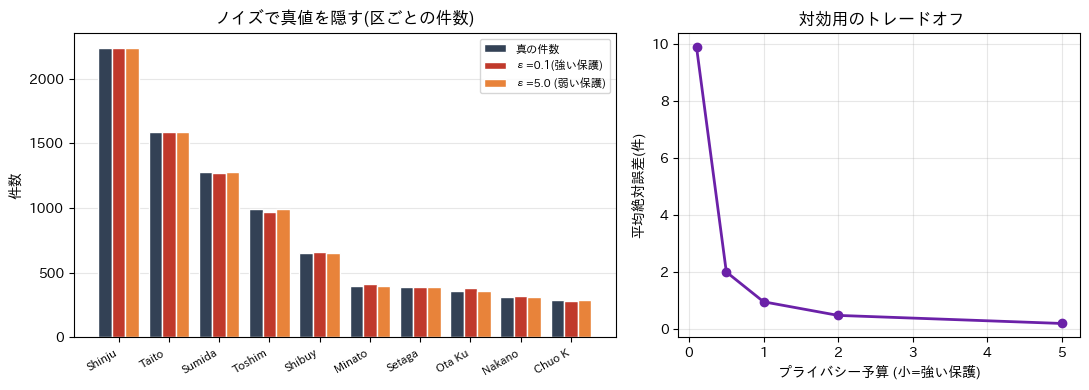

In [7]:
print("\n=== ③ 差分プライバシー(区ごとの件数クエリにLaplaceノイズ) ===")
counts = df["neighbourhood"].value_counts().sort_values (ascending=False).head(10)
sens =1.0 # count query の感度
eps_list=[0.1,0.5,1.0,2.0,5.0]
mae =[]
for eps in eps_list:
    scale=sens/eps
    errs=[]
    for _ in range(200):
        noisy=counts.values + RNG.laplace(0, scale, size=len(counts))
        errs.append(np.mean(np.abs(noisy-counts.values)))
    mae.append(np.mean(errs))
    print(f" ε={eps:.1f}:平均絶対誤差 {np.mean(errs):6.1f} 件(scale={scale:.1f})")

#図③:左=真値 vs ノイズ(小/大)、右=誤差 VSE
fig, (a1,a2)=plt.subplots(1,2, figsize =(11,4), gridspec_kw={"width_ratios": [1.35,1]})
xw=np.arange(len(counts)); ww=0.27
noisy_lo=counts.values+RNG.laplace(0,sens/0.1,size=len(counts))
noisy_hi=counts.values+RNG.laplace(0, sens/5.0, size=len(counts))
a1.bar(xw-ww,counts.values, ww, label="真の件数", color="#334155", edgecolor="white")
a1.bar(xw, np.maximum(noisy_lo,0),ww,label="ε=0.1(強い保護)", color="#C0392B",edgecolor="white")
a1.bar(xw+ww,np.maximum(noisy_hi,0),ww,label="ε=5.0 (弱い保護)", color="#E8833A",edgecolor="white")
a1.set_xticks(xw); a1.set_xticklabels ([c[:6] for c in counts.index], rotation =30,ha="right", fontsize =8)
a1.set_ylabel("件数"); a1.set_title("ノイズで真値を隠す(区ごとの件数)"); a1.legend(fontsize =8)
a1.grid(axis="y", alpha=.3); a1.set_axisbelow (True)

a2.plot(eps_list, mae, "o-",color="#6B21A8", lw=2)
a2.set_xlabel("プライバシー予算 (小=強い保護)"); a2.set_ylabel("平均絶対誤差(件)")
a2.set_title(" 対効用のトレードオフ"); a2.grid(alpha =.3); a2.set_axisbelow(True)
plt.tight_layout(); plt.show()


=== ④ 再現性(seed無し20回 vs seed固定) ===
 seed無し20回: 正解率 0.748~0.775 幅=0.027
 seed固定 : 正解率0.783(毎回同じ)


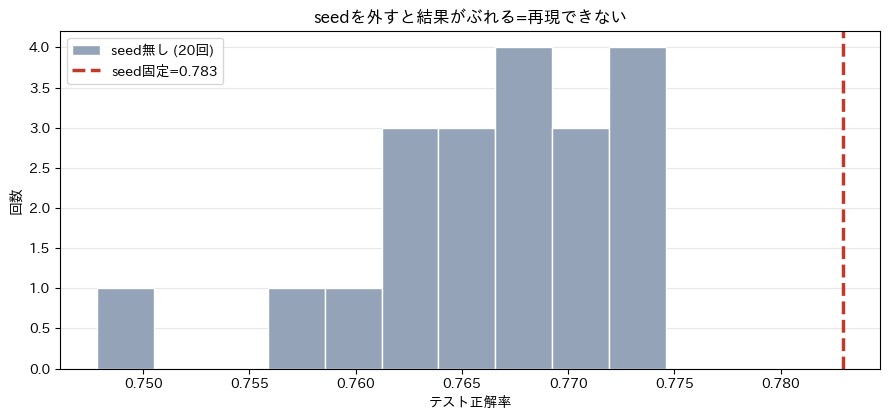

In [8]:
print("\n=== ④ 再現性(seed無し20回 vs seed固定) ===")
accs_noseed=[]
for i in range(20):
    Xa, Xb, ya, yb = train_test_split(X,y, test_size =0.25,stratify=y) # random_stateなし
    mm=make_gbdt(); mm.fit(Xa,ya)
    accs_noseed.append(accuracy_score (yb, mm.predict(Xb)))
accs_noseed=np.array(accs_noseed)

# seed固定
Xa, Xb, ya,yb=train_test_split(X,y,test_size =0.25,stratify=y, random_state=0)
mm=make_gbdt(); mm.fit(Xa,ya); acc_seed=accuracy_score(yb,mm.predict(Xb))

print(f" seed無し20回: 正解率 {accs_noseed.min():.3f}~{accs_noseed.max():.3f} 幅={accs_noseed.max()-accs_noseed.min():.3f}")
print(f" seed固定 : 正解率{acc_seed:.3f}(毎回同じ)")

fig,ax=plt.subplots (figsize =(9,4.3))
ax.hist(accs_noseed, bins =10,color="#94A3B8",edgecolor="white", label="seed無し (20回)")
ax.axvline(acc_seed, color="#C0392B", lw=2.5,ls="--",label=f"seed固定={acc_seed:.3f}")
ax.set_xlabel("テスト正解率"); ax.set_ylabel("回数")
ax.set_title("seedを外すと結果がぶれる=再現できない")
ax.legend(); ax.grid(axis="y", alpha =.3); ax.set_axisbelow (True)
plt.tight_layout(); plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')